<a href="https://colab.research.google.com/github/meganjohnson0522/INFO648/blob/main/Homeworks/Homework_5_INFO_648.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PART 1

In [ ]:
import pandas as pd

df = pd.read_csv('churn_synthetic_600.csv')
df.head(10)

,CustomerID,Churn,TenureMonths,MonthlyCharge,ContractType,PaymentMethod,SupportCalls
0,C0001,1,20,86.27,One-Year,Credit Card,3
1,C0002,0,1,64.80,Month-to-Month,Electronic Check,1
2,C0003,1,20,75.02,Month-to-Month,Credit Card,3
3,C0004,0,18,61.21,Month-to-Month,Bank Transfer,2
4,C0005,0,63,66.20,Two-Year,Bank Transfer,0
5,C0006,0,16,65.09,Two-Year,Bank Transfer,1
6,C0007,0,9,71.58,Month-to-Month,Bank Transfer,2
7,C0008,1,72,68.71,Two-Year,Credit Card,2
8,C0009,0,65,80.73,Two-Year,Credit Card,0
9,C0010,1,70,76.91,Two-Year,Electronic Check,2


In [ ]:
class_counts = df['Churn'].value_counts()
class_props  = df['Churn'].value_counts(normalize=True)

print('Class counts:')
print(class_counts)
print()
print('Class proportions:')
print(class_props.round(4))

Class counts:
Churn
0    458
1    142
Name: count, dtype: int64

Class proportions:
Churn
0    0.7633
1    0.2367
Name: proportion, dtype: float64


In [ ]:
majority_class_accuracy = class_props.max()
print(f'Majority-class baseline accuracy: {majority_class_accuracy:.4f} ({majority_class_accuracy*100:.2f}%)')

Majority-class baseline accuracy: 0.7633 (76.33%)


This dataset is imbalanced. Of the 600 customers, 458 did not churn and 142 did, which is about 3.2 to 1.

When one class dominates, a model can appear to perform well simply by favoring the majority class in nearly every prediction. Standard accuracy blends together performance on both classes and hides how poorly the model may be doing on the smaller class.

A trivial model that predicts "no churn" for every single customer would be correct 76.33% of the time. The number sounds strong, but it tells us almost nothing about whether the model can actually catch churners, which is the entire point of building it.

## PART 2

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Which features are numeric and which are categorical?
# 'TenureMonths', 'MonthlyCharge', 'SupportCalls', 'ContractType', 'PaymentMethod'

numeric_features     = ['TenureMonths', 'MonthlyCharge', 'SupportCalls']
categorical_features = ['ContractType', 'PaymentMethod']


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print('Numeric features    → StandardScaler')
print('Categorical features → OneHotEncoder')

Numeric features    → StandardScaler
Categorical features → OneHotEncoder


StandardScaler subtracts the mean and divides by the standard deviation so every numeric feature contributes on a comparable scale, allowing the solver to converge faster and more reliably.

Logistic regression multiplies features by numeric weights, so it cannot work
directly with text labels. OneHotEncoder converts each category into a set of
binary columns without imposing any false ordering. If we used
simple integer codes, the model would wrongly treat "Two-Year" as twice "One-Year," which is wrong.

Fitting a scaler or encoder on the full dataset before splitting means the test
set's statistics have already leaked into the training process. This produces an overly optimistic result because the model has effectively "seen" the test data. Fitting inside a pipeline ensures all preprocessing parameters are learned
from the training set.

##PART 3

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [ ]:
# Drop identifier; define features and target
# 'CustomerID', 'Churn', 'TenureMonths', 'MonthlyCharge', 'SupportCalls', 'ContractType', 'PaymentMethod'
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# ColumnTransformer: different transforms for each feature group
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),                        numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"),  categorical_features)
    ]
)

In [ ]:
# Full pipeline: preprocessing + logistic regression
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf",        LogisticRegression(max_iter=2000))
    ]
)

In [ ]:
# Fit on training data only
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

As we found in Part 1, the dataset is imbalanced at roughly a 3.2 to 1 ratio. Without stratification, a random split could place a disproportionately small number of churners in the test, which would be unreliable. Setting stratify=y guarantees that both the training set reflects the same ratio as the full dataset.

##PART 4

In [ ]:
y_pred = model.predict(X_test)

[[84  8]
 [16 12]]


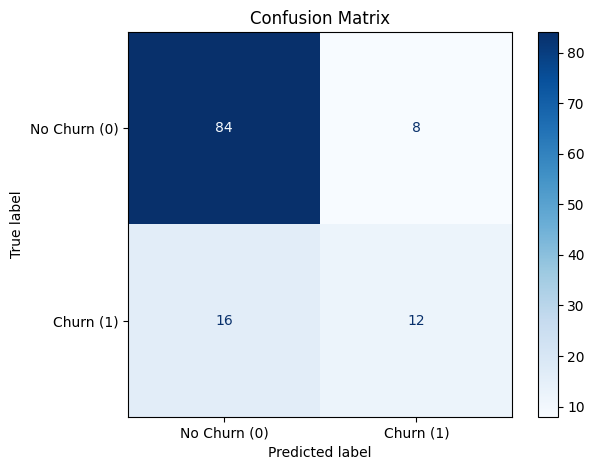

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)

print(f'Accuracy  : {acc:.4f}')
print(f'Precision (churn class): {prec:.4f}')
print(f'Recall    (churn class): {rec:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'], digits=3))

Accuracy  : 0.8000
Precision (churn class): 0.6000
Recall    (churn class): 0.4286

              precision    recall  f1-score   support

    No Churn      0.840     0.913     0.875        92
       Churn      0.600     0.429     0.500        28

    accuracy                          0.800       120
   macro avg      0.720     0.671     0.688       120
weighted avg      0.784     0.800     0.787       120



**What each cell of the confusion matrix means in churn terms:**

- **True Negatives (84):** The model predicted these 84 customers would stay,
and they actually did stay. These are correctly identified customers.

- **False Positives (8):** The model predicted these 8 customers would churn,
but they actually stayed. These customers would receive an unnecessary retention
offer.

- **False Negatives (16):** The model predicted these 16 customers would stay,
but they actually churned. These are the most costly mistakes.

- **True Positives (12):** The model correctly flagged these 12 customers as
likely to churn. These are the customers a retention program can actually act on
and potentially save.

**Precision and recall tied back to those cells:**

Precision (0.60) is TP / (TP + FP) = 12 / (12 + 8). Of every customer we
flagged as a churner, 60% actually were so 40% of our alerts were
false alarms.

Recall (0.43) is TP / (TP + FN) = 12 / (12 + 16). Of the 28 customers
who actually churned, we only caught 43% meaning more than half of real
churners were missed.

**Did the model learn something useful?**

The majority baseline from Part 1 achieves 76.33% accuracy by predicting
"no churn" for every customer. Our model reaches 80% accuracy, which is only about 4 points higher, but it identifies 12 real churners that the baseline would have missed. The non-zero precision and recall on the churn class confirm
the model has learned genuine patterns. However, a recall of 43% means the
majority of at-risk customers are still being missed, so there is room for improvement.

## PART 5

In [ ]:
import numpy as np

# Retrieve feature names after one-hot encoding
feature_names = model.named_steps['preprocess'].get_feature_names_out()

# Retrieve logistic regression coefficients
coefs = model.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefs
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

                            Feature  Coefficient
   cat__ContractType_Month-to-Month     0.773280
                 num__MonthlyCharge     0.589619
                  num__SupportCalls     0.401881
cat__PaymentMethod_Electronic Check     0.113775
     cat__PaymentMethod_Credit Card    -0.043374
   cat__PaymentMethod_Bank Transfer    -0.071576
         cat__ContractType_One-Year    -0.076857
         cat__ContractType_Two-Year    -0.697598
                  num__TenureMonths    -0.924292


In [ ]:
print('\nTop features pushing TOWARD churn (positive):')
print(coef_df.head(3).to_string(index=False))
print('\nTop features pushing AWAY from churn (negative):')
print(coef_df.tail(3).to_string(index=False))


Top features pushing TOWARD churn (positive):
                         Feature  Coefficient
cat__ContractType_Month-to-Month     0.773280
              num__MonthlyCharge     0.589619
               num__SupportCalls     0.401881

Top features pushing AWAY from churn (negative):
                   Feature  Coefficient
cat__ContractType_One-Year    -0.076857
cat__ContractType_Two-Year    -0.697598
         num__TenureMonths    -0.924292


SupportCalls carries a positive coefficient, meaning that as the number
of support calls a customer makes increases, the model's predicted probability
of churn rises meaningfully. In business terms, a customer who contacts support
frequently is signaling frustration, repeated calls suggest unresolved issues,
a poor product experience, or dissatisfaction with service quality. These
customers are actively struggling and, without intervention, are likely looking
for alternatives.

##PART 6

**Precision (churn class): 0.60**

**Recall (churn class): 0.43**

---

**Business cost of low precision:**

Low precision means many customers we flag as likely churners are actually
loyal customers who had no intention of leaving. In a churn-prevention program,
these false positives receive retention offers like discounts, personal outreach, or loyalty perks which they did not need. The direct cost is financial: we spend money on customers who would have stayed anyway. At scale, a precision of 60% means that for every 10 retention offers sent, 4 went to customers who were never going to leave.

**Business cost of low recall:**

Low recall means a large share of customers who genuinely intend to churn are
completely missed. They never receive a retention offer, and the company loses
their future revenue with no chance to intervene. In a subscription business,
each missed churner represents not just one lost payment but the entire remaining lifetime value of that customer. Our recall of 43% means that out of every 10 customers who actually churn, we only catch 4 and the other 6 walk out the door undetected.

**Which should we prioritize, and why?**

For a churn-prevention program, recall should be prioritized over precision.
The cost of a false positive is a wasted retention offer. The cost of a false negative is the complete and unrecoverable loss of a customers's future revenue, which in most subscription businesses far exceeds the cost of a single retention offer.